<h1 style="text-align: center;">Assessment 2: FIS 2</h1>
<h2 style="text-align: center;">Soft Computing</h2> 
<h3 style="text-align: center;">By Ruhan Shafi | u3284342</h3>

### `FIS2`: This `FIS` is designed to minimise the average waiting times for cars on the main street.

## Setup and Imports


In [1]:

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import trafficSimulator as trafficSimulator


## Inputs and Outputs
In this cell, the fuzzy inputs and outputs are being decleared, through the use of the `skfuzzy` functions, `ctrl.Antecedent(universe, label)` & `ctrl.Consequent(universe, label)` respectively. These inputs and outputs are used in Membership Function Defination and provides dictionary interfaces used in the construction of the `FIS`. 

In [2]:
waitingTraffic  = ctrl.Antecedent(np.arange(1, 100, 1), 'waiting')
incomingTraffic = ctrl.Antecedent(np.arange(0, 100, 1), 'incoming')

waitingDuration = ctrl.Consequent(np.arange(0, 120, 1), 'wait duration')
openDuration    = ctrl.Consequent(np.arange(0, 120, 1), 'open duration')


## Membership Functions

Once the fuzzy inputs has been defined, the next step is to specifies membership functions. These describe fuzzy categories such as low, medium, and high. For example, the side street queue (`waitingTraffic`) and the main street input (`incomingTraffic`) has three categories:
* Low: defined as a triangle starting at 1, peaking at 1, and dropping to 0 at 25. This acts like a left shoulder, meaning that if the waiting cars are between 1 and 25, they are considered “low,” with the strongest membership at very small values.
* Medium: a triangle centered at 50 with sides at 15 and 85. This means a queue of around 50 is fully “medium,” while smaller or larger queues partly belong to this category.
* High: a triangle starting at 75, peaking at 99, and ending at 99. This acts like a right shoulder, so queues close to 100 cars are strongly “high.”

In [3]:

# Side Traffic MFs (Key change: Tuned 'High' to act as the 'Critical' override)
waitingTraffic['low']    = fuzz.trimf(waitingTraffic.universe, [1, 1, 25])
waitingTraffic['medium'] = fuzz.trimf(waitingTraffic.universe, [15, 45, 75])
waitingTraffic['high']   = fuzz.trapmf(waitingTraffic.universe, [65, 85, 99, 99]) # Focuses on high queue size

# Main Traffic MFs (Standard, but with a clear 'High' focus)
incomingTraffic['low']    = fuzz.trimf(incomingTraffic.universe, [0, 0, 30])
incomingTraffic['medium'] = fuzz.trimf(incomingTraffic.universe, [20, 50, 80])
incomingTraffic['high']   = fuzz.trimf(incomingTraffic.universe, [65, 99, 99])

# Output MFs (Main Duration skewed toward 'Long' for priority)
waitingDuration['short'] = fuzz.trimf(waitingDuration.universe, [0, 15, 45])
waitingDuration['long']  = fuzz.trimf(waitingDuration.universe, [40, 80, 120])
openDuration['short'] = fuzz.trimf(openDuration.universe, [0, 10, 30])
openDuration['medium'] = fuzz.trimf(openDuration.universe, [20, 50, 70])
openDuration['long']  = fuzz.trimf(openDuration.universe, [60, 90, 120])



## 3. Fuzzy Rules

Object: Main street gets 'Long' unless it's 'Low' AND Side is 'High'.

This FIS has 6 rules that capture how the traffic light should behave while placing priority on the Main Street across 4 different cases

* Main Street Priority 
* Side Critical Override - Prevents the side street from being ignored forever. If the side street is heavily backed up while the main street has low traffic, then the system flips priorities
* Balanced but Still Main-Favored - In this case, the main street is still prioritized: it gets a long green, while the side street only gets a medium green despite being “high.”
* Low Traffic - If both streets are low, then both get a short green


In [ ]:


# Case 1: Max Main Priority (When Main is High, or Main is Medium/High and Side is not critically high)
rule1 = ctrl.Rule(incomingTraffic['high'], 
                  (waitingDuration['long'], openDuration['short']))
rule2 = ctrl.Rule(incomingTraffic['medium'] & waitingTraffic['low'], 
                  (waitingDuration['long'], openDuration['short']))
rule3 = ctrl.Rule(incomingTraffic['medium'] & waitingTraffic['medium'], 
                  (waitingDuration['long'], openDuration['medium']))

# Case 2: Side Critical Override (The Escape Valve)
# Only allow side to be long when its queue is 'High' AND Main queue is 'Low'.
rule4 = ctrl.Rule(waitingTraffic['high'] & incomingTraffic['low'],
                  (waitingDuration['short'], openDuration['long'])) 

# Case 3: Balanced/Less Extreme High Traffic
rule5 = ctrl.Rule(waitingTraffic['high'] & incomingTraffic['medium'],
                  (waitingDuration['long'], openDuration['medium'])) # Still prioritize main, but give side medium time

# Case 4: Low Traffic
rule6 = ctrl.Rule(incomingTraffic['low'] & waitingTraffic['low'], 
                  (waitingDuration['short'], openDuration['short']))



## System Usage

Compiling the Model with the defined rules and making it ready for the Traffic Simulation

In [ ]:
fis_ctrl_main_compliant = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6])
fis_simulator_main_compliant = ctrl.ControlSystemSimulation(fis_ctrl_main_compliant)

## Debug and Sanity Check
While this section of code has no real impact on the final performance on the `FIS` model, it was used in to development of the model to check if the distribution of priority between the main and side road. `FIS1` has equal priority while `FIS2` has greater priority placed on the Main Road.

In [ ]:

fis_simulator_main_compliant.input['waiting'] = 45 
fis_simulator_main_compliant.input['incoming'] = 60
fis_simulator_main_compliant.compute()
print("[DEBUG] Main Priority FIS: Wait (Main Duration):", fis_simulator_main_compliant.output['wait duration'],
      "Open (Side Duration):", fis_simulator_main_compliant.output['open duration'])

[DEBUG] Main Priority FIS: Wait (Main Duration): 79.9861670118401 Open (Side Duration): 46.38888888888889


## Simulation and Metrics


--- Compliant Main Priority FIS Metrics ---
mean_wait_main: 230.75
mean_wait_side: 51.86
diff_wait: 178.89
max_wait_main: 449.14
max_wait_side: 100.86
throughput_main: 941.00
throughput_side: 102.00
total_throughput: 1043.00
fairness_index: 0.71
avg_queue_main: 370.31
avg_queue_side: 2.62
max_queue_main: 674.00
max_queue_side: 15.00


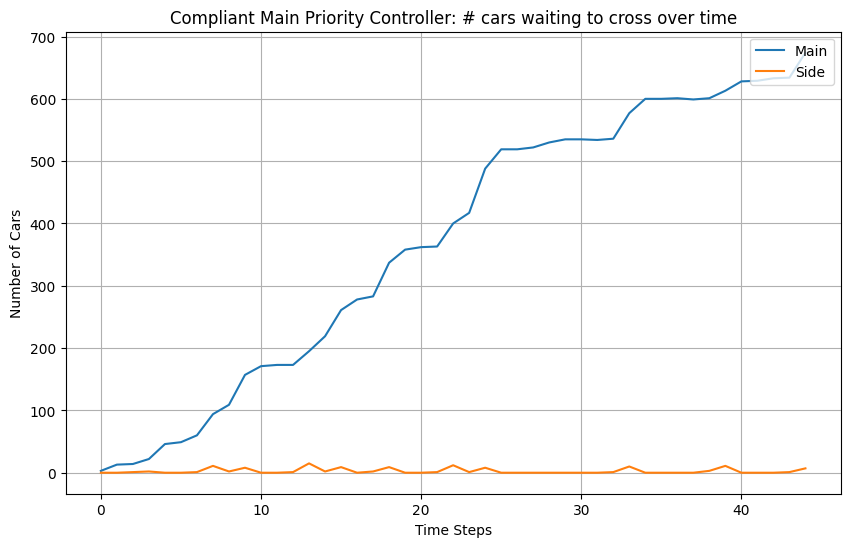

In [ ]:

# Run the traffic simulator with the defined FIS controller
num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side = trafficSimulator.simulate(fis_simulator_main_compliant, verbose = False)

# Differment metrics used for eval and their calculation code + formatting/plotting 
def evaluate_metrics(num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side):
    metrics = {}
    metrics['mean_wait_main'] = np.mean(wait_times_main) if len(wait_times_main) > 0 else 0
    metrics['mean_wait_side'] = np.mean(wait_times_side) if len(wait_times_side) > 0 else 0
    metrics['diff_wait']      = abs(metrics['mean_wait_main'] - metrics['mean_wait_side'])
    metrics['max_wait_main']  = np.max(wait_times_main) if len(wait_times_main) > 0 else 0
    metrics['max_wait_side']  = np.max(wait_times_side) if len(wait_times_side) > 0 else 0
    metrics['throughput_main'] = len(wait_times_main)
    metrics['throughput_side'] = len(wait_times_side)
    metrics['total_throughput'] = metrics['throughput_main'] + metrics['throughput_side']
    
    waits = np.array([metrics['mean_wait_main'], metrics['mean_wait_side']])
    metrics['fairness_index'] = (np.sum(waits)**2) / (len(waits) * np.sum(waits**2)) if np.sum(waits) > 0 else 1
    
    metrics['avg_queue_main'] = np.mean(num_cars_on_main)
    metrics['avg_queue_side'] = np.mean(num_cars_on_side)
    metrics['max_queue_main'] = np.max(num_cars_on_main)
    metrics['max_queue_side'] = np.max(num_cars_on_side)
    return metrics

metrics = evaluate_metrics(num_cars_on_main, num_cars_on_side, wait_times_main, wait_times_side)
print("\n--- Compliant Main Priority FIS Metrics ---")
for k, v in metrics.items():
    print(f"{k}: {v:.2f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(num_cars_on_main)
plt.plot(num_cars_on_side)
plt.legend(["Main", "Side"], loc="upper right")
plt.title("Compliant Main Priority Controller: # cars waiting to cross over time")
plt.xlabel("Time Steps")
plt.ylabel("Number of Cars")
plt.grid(True)
plt.show()

# Report



```--- Compliant Fairness FIS Metrics ---
mean_wait_main: 226.63
mean_wait_side: 57.65
diff_wait: 168.98
max_wait_main: 442.30
max_wait_side: 123.98
throughput_main: 946.00
throughput_side: 110.00
total_throughput: 1056.00
fairness_index: 0.74
avg_queue_main: 339.68
avg_queue_side: 3.46
max_queue_main: 657.00
max_queue_side: 16.00

--- Compliant Main Priority FIS Metrics ---
mean_wait_main: 230.75
mean_wait_side: 51.86
diff_wait: 178.89
max_wait_main: 449.14
max_wait_side: 100.86
throughput_main: 941.00
throughput_side: 102.00
total_throughput: 1043.00
fairness_index: 0.71
avg_queue_main: 370.31
avg_queue_side: 2.62
max_queue_main: 674.00
max_queue_side: 15.00```

The different metrics for `FIS2` show that the priority bias was successfully implemented due to the value of `diff_wait` being `178.89`. A consequence of this priority bias is that `avg_queue_main` is 370.31, which indicates that refinements are required in order to ensure that the unprioritized street will still go off. Another thing to note is that `mean_wait_main` value of 230.75, indicating that even with priority, the main street is experiencing significant congestion and delay.